# Visualization of Results

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
wandb.login()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: mohkoh. Use `wandb login --relogin` to force relogin


True

## Global Settings

In [2]:
color_mapping = {
    "GPSL": "#377EB8",  # Muted blue
    "FPLS": "#4DAF4A",  # Muted green
    "FLS": "#984EA3",   # Muted purple
    "CL": "#000000"
}

dataset = "ham10k"
B = 64
K = 16

dataset = "cifar10"
B = 128
K = 64

PROJECT_NAME = "inda/gpsl"

# Initialize a W&B API client
api = wandb.Api()

# Get all runs in the project
runs = api.runs(PROJECT_NAME)

## Batch Deviation

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

# Prepare DataFrame
df = pd.DataFrame(
    columns=[
        "run_id",
        "method",
        "batch_size",
        "num_clients",
        "dataset",
        "batch_deviation",
        "step",
    ]
)

# Fill df from runs
for run in runs:
    data_config = run.config.get("data", None)
    distributed_config = run.config.get("distributed", None)
    
    if distributed_config is None: 
        continue
    
    if dataset not in data_config["_target_"].lower():
        continue

    if not int(data_config["batch_size"]) == B:
        continue

    if int(distributed_config["num_clients"]) not in [K, 1]:
        continue

    history = run.history(keys=["train/batch_deviation"])
    for index, row in history.iterrows():
        new_row = {
            "run_id": run.id,
            "method": distributed_config["sampler"]["_target_"].split(".")[-1],
            "batch_size": data_config["batch_size"],
            "num_clients": distributed_config["num_clients"],
            "dataset": data_config["_target_"],
            "step": row.get("_step", None),
            "batch_deviation": row.get("train/batch_deviation", None)
        }
        df.loc[len(df)] = new_row

# Set method to 'CL' for num_clients == 1
df.loc[df["num_clients"] == 1, "method"] = "CL"

# Group data
grouped = (
    df.groupby(["method", "step"])["batch_deviation"].agg(["mean", "std"]).reset_index()
)

# Rename methods for clarity
grouped["method"] = grouped["method"].replace({
    "UniformGlobalSampler": "GPSL",
    "LocalFixedSampler": "FPLS",
    "LocalFixedSamplerNonProportional": "FLS",
})


/tmp/ipykernel_281079/3770924152.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["upper"] = subset["smoothed_mean"] + subset["std"].ewm(span=smoothing_window, adjust=False).mean()
/tmp/ipykernel_281079/3770924152.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["lower"] = subset["smoothed_mean"] - subset["std"].ewm(span=smoothing_window, adjust=False).mean()
/tmp/ipykernel_281079/3770924152.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so res

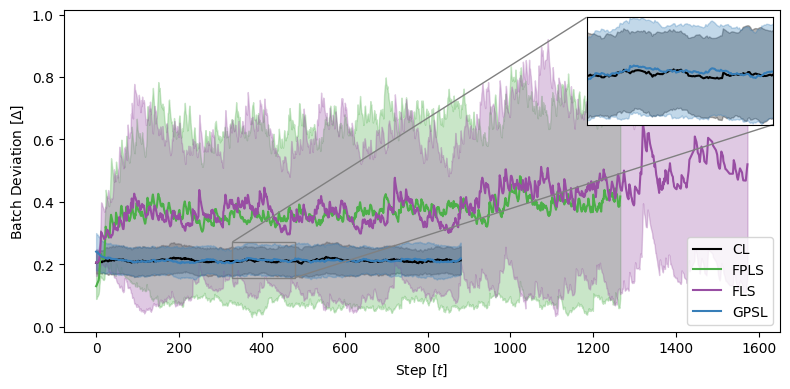

In [15]:
# Exponential moving average
smoothing_window = 50
grouped["smoothed_mean"] = grouped.groupby("method")["mean"].transform(
    lambda x: x.ewm(span=smoothing_window, adjust=False).mean()
)

# Auto-zoom: Find window where CL and GPSL differ most
cl_data = grouped[grouped["method"] == "CL"][["step", "smoothed_mean"]].reset_index(drop=True)
ugs_data = grouped[grouped["method"] == "GPSL"][["step", "smoothed_mean"]].reset_index(drop=True)
diff = pd.DataFrame({
    "step": cl_data["step"],
    "abs_diff": np.abs(cl_data["smoothed_mean"] - ugs_data["smoothed_mean"])
})
window_size = 150
rolling_diff = diff["abs_diff"].rolling(window=window_size).mean()
max_index = rolling_diff.idxmax()
zoom_region = (
    int(diff.loc[max_index, "step"]),
    int(diff.loc[max_index, "step"]) + window_size
)

# Plotting
plt.figure(figsize=(8, 4))
ax = plt.gca()

methods = grouped["method"].unique()

for method in methods:
    method_data = grouped[grouped["method"] == method].sort_values("step")
    smoothed_mean_ema = method_data["smoothed_mean"]
    smoothed_std_ema = method_data["std"].ewm(span=smoothing_window, adjust=False).mean()

    color = color_mapping.get(method, "#000000")
    ax.plot(
        method_data["step"], smoothed_mean_ema, label=method, color=color, linewidth=1.5
    )
    ax.fill_between(
        method_data["step"],
        smoothed_mean_ema - smoothed_std_ema,
        smoothed_mean_ema + smoothed_std_ema,
        color=color,
        alpha=0.3,
    )

plt.xlabel("Step $\left[t\\right]$")
plt.ylabel("Batch Deviation $\left[ \Delta\\right]$")
plt.legend(loc="lower right")

# === Add Inset Zoom for CL vs GPSL ===
axins = zoomed_inset_axes(ax, zoom=3, loc="upper right")

for method in ["CL", "GPSL"]:
    method_data = grouped[grouped["method"] == method].sort_values("step")
    smoothed_mean = method_data["smoothed_mean"]
    smoothed_std = method_data["std"].ewm(span=smoothing_window, adjust=False).mean()
    color = color_mapping.get(method, "#000000")

    axins.plot(method_data["step"], smoothed_mean, color=color, linewidth=1.5)
    axins.fill_between(
        method_data["step"],
        smoothed_mean - smoothed_std,
        smoothed_mean + smoothed_std,
        color=color,
        alpha=0.3,
    )

# Limit inset to zoom region
axins.set_xlim(*zoom_region)
subset = grouped[
    (grouped["method"].isin(["CL", "GPSL"])) &
    (grouped["step"] >= zoom_region[0]) &
    (grouped["step"] <= zoom_region[1])
]
# axins.set_ylim(subset["smoothed_mean"].min() - 0.01, subset["smoothed_mean"].max() + 0.01)

# Get the upper and lower bounds including std
subset["upper"] = subset["smoothed_mean"] + subset["std"].ewm(span=smoothing_window, adjust=False).mean()
subset["lower"] = subset["smoothed_mean"] - subset["std"].ewm(span=smoothing_window, adjust=False).mean()

axins.set_ylim(
    subset["lower"].min(),
    subset["upper"].max()
)

axins.set_xticks([])
axins.set_yticks([])
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
plt.show()

## Training Time

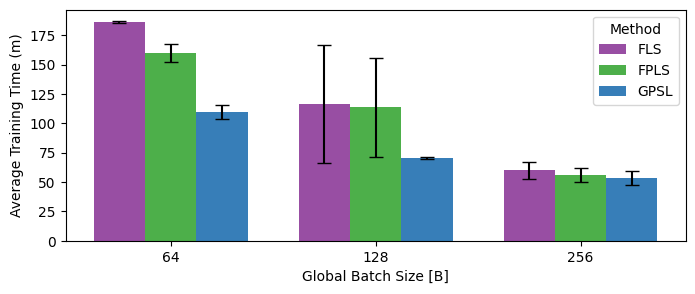

In [30]:
df = pd.DataFrame(
    columns=[
        "run_id",
        "method",
        "batch_size",
        "num_clients",
        "dataset",
        "runtime"
    ]
)

for run in runs:
    data_config = run.config.get("data", None)
    distributed_config = run.config.get("distributed", None)
    
    if distributed_config is None: 
        continue
    
    if dataset not in data_config["_target_"].lower():
        continue

    # if not int(data_config["batch_size"]) == B:
    #     continue

    if not int(distributed_config["num_clients"]) == K:
        continue
    
    # filter out runtime that is higher than 3h
    if run.summary.get("_runtime", None) / 60 > 200:
        continue
    
    runtime = run.summary.get("_runtime", None)
    
    new_row = {
        "run_id": run.id,
        "method": distributed_config["sampler"]["_target_"].split(".")[-1],
        "batch_size": data_config["batch_size"],
        "num_clients": distributed_config["num_clients"],
        "dataset": data_config["_target_"],
        "runtime": runtime
    }
    df.loc[len(df)] = new_row
    
# Group by batch size and method, then aggregate mean and standard deviation for runtime.
stats = df.groupby(["batch_size", "method"])["runtime"].agg(["mean", "std"]).reset_index()

# Rename methods for better readability using the provided mappings.
rename_mapping = {
    "UniformGlobalSampler": "GPSL",
    "LocalFixedSampler": "FPLS",
    "LocalFixedSamplerNonProportional": "FLS"
}
stats["method"] = stats["method"].replace(rename_mapping)

# Convert runtime seconds to minutes for better readability.
stats["mean_sec"] = stats["mean"] / 60
stats["std_sec"] = stats["std"] / 60

# Define the desired order for the methods.
ordered_methods = ["FLS", "FPLS", "GPSL"]
stats["method"] = pd.Categorical(stats["method"], categories=ordered_methods, ordered=True)
stats = stats.sort_values(["batch_size", "method"])

# Get unique batch sizes and prepare x-axis positions.
batch_sizes = stats["batch_size"].unique()
x = np.arange(len(batch_sizes))
width = 0.25  # width of each bar

plt.figure(figsize=(8, 3))
for i, method in enumerate(ordered_methods):
    subset = stats[stats["method"] == method].sort_values("batch_size")
    plt.bar(x + i * width, subset["mean_sec"], width,
            yerr=subset["std_sec"], capsize=5,
            label=method,
            color=color_mapping[method])

plt.xlabel("Global Batch Size [B]")
plt.ylabel("Average Training Time (m)")
# plt.title("Total Training Time per Batch Size")
plt.xticks(x + width, batch_sizes)
plt.legend(title="Method")
plt.show()


## Test Accuracy

In [17]:
df = pd.DataFrame(
    columns=[
        "run_id",
        "method",
        "test_accuracy",
        "epoch"
    ]

)

for run in runs:
    data_config = run.config.get("data", None)
    distributed_config = run.config.get("distributed", None)
    
    if distributed_config is None: 
        continue
    
    if dataset not in data_config["_target_"].lower():
        continue
    
    if distributed_config["num_clients"] not in [1, 64] or data_config["batch_size"] != 128:
        continue
    
    # Load per-step history for test accuracy
    history = run.history(keys=["test/acc", "epoch"])
    for index, row in history.iterrows():
        method = "CL" if distributed_config["num_clients"] == 1 else distributed_config["sampler"]["_target_"].split(".")[-1]
        new_row = {
            "run_id": run.id,
            "method": method,
            "test_accuracy": row.get("test/acc", None),
            "epoch": row.get("epoch", None),
        }
        df.loc[len(df)] = new_row


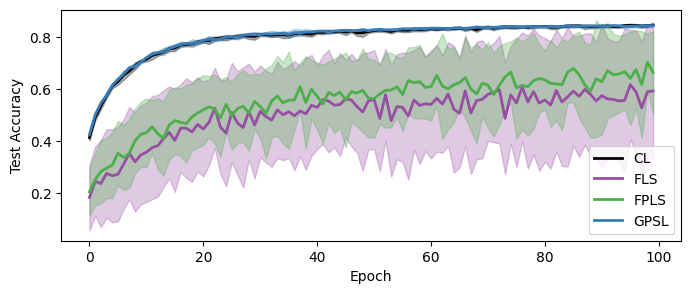

In [18]:
# Group by method and epoch, then compute the mean and std for test accuracy
grouped_accuracy = df.groupby(["method", "epoch"])["test_accuracy"].agg(["mean", "std"]).reset_index()

# Rename methods for better readability
rename_mapping = {
    "UniformGlobalSampler": "GPSL",
    "LocalFixedSampler": "FPLS",
    "LocalFixedSamplerNonProportional": "FLS"
}
grouped_accuracy["method"] = grouped_accuracy["method"].replace(rename_mapping)

# Order the methods (FLS, FPLS, GPSL)
ordered_methods = ["CL", "FLS", "FPLS", "GPSL"]
grouped_accuracy["method"] = pd.Categorical(grouped_accuracy["method"], 
                                             categories=ordered_methods, 
                                             ordered=True)
grouped_accuracy = grouped_accuracy.sort_values(["epoch", "method"])

# Convert the epoch, mean, and std columns to numeric types
grouped_accuracy["epoch"] = pd.to_numeric(grouped_accuracy["epoch"], errors="coerce")
grouped_accuracy["mean"] = pd.to_numeric(grouped_accuracy["mean"], errors="coerce")
grouped_accuracy["std"] = pd.to_numeric(grouped_accuracy["std"], errors="coerce")

plt.figure(figsize=(8, 3))
for method in ordered_methods:
    data = grouped_accuracy[grouped_accuracy["method"] == method].sort_values("epoch")
    plt.plot(data["epoch"], data["mean"], label=method, color=color_mapping[method], linewidth=2)
    plt.fill_between(data["epoch"].astype(float),
                     (data["mean"] - data["std"]).astype(float),
                     (data["mean"] + data["std"]).astype(float),
                     color=color_mapping[method],
                     alpha=0.3)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
# plt.title("Test Accuracy vs Epoch")
plt.legend()
plt.show()

## Tables

In the following are our main table results that need to be filled with the results from the experiments in wandb:

In [3]:
# hparams

non_iid_degree = {
    "cifar10": {
        "mild": {"C": 5, "alpha": 3},
        "severe": {"C": 2, "alpha": 3},
    },
    "ham10k": {"mild": {"C": 5, "alpha": 10}, "severe": {"C": 3, "alpha": 10}},
}

df = pd.DataFrame(
    columns=[
        "run_id",
        "method",
        "test_accuracy",
        "batch_size",
        "num_clients",
        "distribution",
        "C",
        "alpha",
    ]
)

for run in runs:
    data_config = run.config.get("data", None)
    distributed_config = run.config.get("distributed", None)
    
    if distributed_config is None: 
        continue
    
    if dataset not in data_config["_target_"].lower():
        continue
    
    method = "CL" if distributed_config["num_clients"] == 1 else distributed_config["sampler"]["_target_"].split(".")[-1]

    new_row = {
        "run_id": run.id,
        "method": method,
        "test_accuracy": run.summary.get("test/acc", None),
        "batch_size": data_config["batch_size"],
        "num_clients": distributed_config["num_clients"],
        "distribution": distributed_config["subset_config"]["distribution"],
        "C": distributed_config["subset_config"]["params"]["C"],
        "alpha": distributed_config["subset_config"]["params"]["alpha"],
    }
    df.loc[len(df)] = new_row

/tmp/ipykernel_281079/2656136783.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[len(df)] = new_row
/tmp/ipykernel_281079/2656136783.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[len(df)] = new_row
/tmp/ipykernel_281079/2656136783.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, 

In [4]:
rename_mapping = {
    "UniformGlobalSampler": "GPSL",
    "LocalFixedSampler": "FPLS",
    "LocalFixedSamplerNonProportional": "FLS"
}

df["method"] = df["method"].replace(rename_mapping)

# Set method to 'CL' for num_clients == 1
df.loc[df["num_clients"] == 1, "method"] = "CL"

# Use the non_iid_degree mapping to replace C and alpha columns with a single column that is "mild" or "severe"
def get_non_iid_degree(row):
    if row["C"] == non_iid_degree[dataset]["mild"]["C"] and row["alpha"] == non_iid_degree[dataset]["mild"]["alpha"]:
        return "mild"
    elif row["C"] == non_iid_degree[dataset]["severe"]["C"] and row["alpha"] == non_iid_degree[dataset]["severe"]["alpha"]:
        return "severe"
    else:
        return "unknown"
    
df["non_iid_degree"] = df.apply(get_non_iid_degree, axis=1)
# Convert the non_iid_degree column to a categorical type with a specific order
df["non_iid_degree"] = pd.Categorical(df["non_iid_degree"], categories=["mild", "severe"], ordered=True)

# Prompt for filling in the missing values
prompt = "fill the table with the following values, make the best value per column bold: "

# Mean and std for test accuracy
grouped = df.groupby(["method", "batch_size", "num_clients", "distribution"])["test_accuracy"].agg(["mean", "std"]).reset_index()

# CL Results
cl_df = grouped[
    (grouped["batch_size"] == 128)
    & (grouped["num_clients"] == 1)
    & (grouped["method"] == "CL")
    & (grouped["distribution"] == "iid")
].copy()
cl_df = cl_df.rename(
    columns={
        "mean": "Test Accuracy",
        "std": "Test Accuracy Std",
    }
)
cl_df["Test Accuracy"] = cl_df["Test Accuracy"].round(4) * 100
cl_df["Test Accuracy Std"] = cl_df["Test Accuracy Std"].round(4) * 100
print("$", cl_df["Test Accuracy"].iloc[0], " \pm ", cl_df["Test Accuracy Std"].iloc[0], "$",)

$ 84.65  \pm  0.42 $


### Table I
$K \in \{16, 32, 64, 128\}$ 

$B = 128$

iid

In [5]:
# Mean and std for test accuracy
grouped = df.groupby(["method", "batch_size", "num_clients", "distribution"])["test_accuracy"].agg(["mean", "std"]).reset_index()

table2_df = grouped[
    
    (grouped["batch_size"] == 128)
    & (grouped["num_clients"].isin([16, 32, 64, 128]))
    & (grouped["method"] != "CL")
    & (grouped["distribution"] == "iid")
].copy()
table2_df = table2_df.sort_values(["num_clients", "method"])
table2_df["method"] = pd.Categorical(
    table2_df["method"], categories=["FLS", "FPLS", "GPSL"], ordered=True
)
table2_df = table2_df.reset_index(drop=True)
table2_df = table2_df.drop(columns=["batch_size"])
table2_df = table2_df.rename(
    columns={
        "num_clients": "K",
        "mean": "Test Accuracy",
        "std": "Test Accuracy Std",
        "method": "Method",
    }
)
table2_df["Test Accuracy"] = table2_df["Test Accuracy"].round(4) * 100
table2_df["Test Accuracy Std"] = table2_df["Test Accuracy Std"].round(4) * 100

print(prompt + table2_df.to_json())

fill the table with the following values, make the best value per column bold: {"Method":{"0":"FLS","1":"FPLS","2":"GPSL","3":"FLS","4":"FPLS","5":"GPSL","6":"FLS","7":"FPLS","8":"GPSL","9":"FPLS","10":"GPSL"},"K":{"0":16,"1":16,"2":16,"3":32,"4":32,"5":32,"6":64,"7":64,"8":64,"9":128,"10":128},"distribution":{"0":"iid","1":"iid","2":"iid","3":"iid","4":"iid","5":"iid","6":"iid","7":"iid","8":"iid","9":"iid","10":"iid"},"Test Accuracy":{"0":84.4,"1":84.44,"2":81.97,"3":84.49,"4":84.49,"5":83.8,"6":84.03,"7":84.53,"8":83.9,"9":84.12,"10":84.13},"Test Accuracy Std":{"0":null,"1":null,"2":3.64,"3":null,"4":null,"5":null,"6":null,"7":null,"8":null,"9":null,"10":null}}


### Table II
$K \in \{16, 32, 64, 128\}$ 

$B = 128$

_severe_ non-iid

In [6]:
# Mean and std for test accuracy
grouped = df.groupby(["method", "non_iid_degree", "batch_size", "num_clients", "distribution"])["test_accuracy"].agg(["mean", "std"]).reset_index()

table2_df = grouped[
    (grouped["batch_size"] == 128)
    & (grouped["num_clients"].isin([16, 32, 64, 128]))
    & (grouped["method"] != "CL")
    & (grouped["distribution"] == "non_iid")
    & (grouped["non_iid_degree"] == "severe")
].copy()
table2_df = table2_df.sort_values(["num_clients", "method"])
table2_df["method"] = pd.Categorical(
    table2_df["method"], categories=["FLS", "FPLS", "GPSL"], ordered=True
)
table2_df = table2_df.reset_index(drop=True)
table2_df = table2_df.drop(columns=["batch_size", "non_iid_degree"])
table2_df = table2_df.rename(
    columns={
        "num_clients": "K",
        "mean": "Test Accuracy",
        "std": "Test Accuracy Std",
        "method": "Method",
    }
)
table2_df["Test Accuracy"] = table2_df["Test Accuracy"].round(4) * 100
table2_df["Test Accuracy Std"] = table2_df["Test Accuracy Std"].round(4) * 100

print(prompt + table2_df.to_json())

fill the table with the following values, make the best value per column bold: {"Method":{"0":"FLS","1":"FPLS","2":"GPSL","3":"FLS","4":"FPLS","5":"GPSL","6":"FLS","7":"FPLS","8":"GPSL","9":"FLS","10":"FPLS","11":"GPSL"},"K":{"0":16,"1":16,"2":16,"3":32,"4":32,"5":32,"6":64,"7":64,"8":64,"9":128,"10":128,"11":128},"distribution":{"0":"non_iid","1":"non_iid","2":"non_iid","3":"non_iid","4":"non_iid","5":"non_iid","6":"non_iid","7":"non_iid","8":"non_iid","9":"non_iid","10":"non_iid","11":"non_iid"},"Test Accuracy":{"0":54.01,"1":49.14,"2":84.37,"3":53.56,"4":63.17,"5":84.43,"6":52.57,"7":64.35,"8":84.71,"9":58.88,"10":70.05,"11":84.31},"Test Accuracy Std":{"0":16.84,"1":14.44,"2":0.23,"3":27.06,"4":5.38,"5":0.03,"6":26.13,"7":20.94,"8":0.03,"9":13.82,"10":12.25,"11":0.28}}


/tmp/ipykernel_281079/1436392224.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["method", "non_iid_degree", "batch_size", "num_clients", "distribution"])["test_accuracy"].agg(["mean", "std"]).reset_index()


### Table III

$K \in \{16, 32, 64, 128\}$

$B = 128$

_mild_ non-iid

In [7]:
# Mean and std for test accuracy
grouped = df.groupby(["method", "non_iid_degree", "batch_size", "num_clients", "distribution"])["test_accuracy"].agg(["mean", "std"]).reset_index()

table3_df = grouped[
    (grouped["batch_size"] == 128)
    & (grouped["num_clients"].isin([16, 32, 64, 128]))
    & (grouped["method"] != "CL")
    & (grouped["distribution"] == "non_iid")
    & (grouped["non_iid_degree"] == "mild")
].copy()
table3_df = table3_df.sort_values(["num_clients", "method"])
table3_df["method"] = pd.Categorical(
    table3_df["method"], categories=["FLS", "FPLS", "GPSL"], ordered=True
)
table3_df = table3_df.reset_index(drop=True)
table3_df = table3_df.drop(columns=["batch_size", "non_iid_degree"])
table3_df = table3_df.rename(
    columns={
        "num_clients": "K",
        "mean": "Test Accuracy",
        "std": "Test Accuracy Std",
        "method": "Method",
    }
)
table3_df["Test Accuracy"] = table3_df["Test Accuracy"].round(4) * 100
table3_df["Test Accuracy Std"] = table3_df["Test Accuracy Std"].round(4) * 100
print(prompt + table3_df.to_json())

fill the table with the following values, make the best value per column bold: {"Method":{"0":"FLS","1":"FPLS","2":"GPSL","3":"FLS","4":"FPLS","5":"GPSL","6":"FLS","7":"FPLS","8":"GPSL","9":"FLS","10":"FPLS","11":"GPSL"},"K":{"0":16,"1":16,"2":16,"3":32,"4":32,"5":32,"6":64,"7":64,"8":64,"9":128,"10":128,"11":128},"distribution":{"0":"non_iid","1":"non_iid","2":"non_iid","3":"non_iid","4":"non_iid","5":"non_iid","6":"non_iid","7":"non_iid","8":"non_iid","9":"non_iid","10":"non_iid","11":"non_iid"},"Test Accuracy":{"0":58.21,"1":67.73,"2":84.5,"3":65.54,"4":65.61,"5":84.22,"6":58.16,"7":63.41,"8":84.3,"9":65.09,"10":54.9,"11":84.21},"Test Accuracy Std":{"0":10.19,"1":15.0,"2":0.24,"3":5.0,"4":11.29,"5":0.29,"6":23.66,"7":9.15,"8":0.65,"9":15.16,"10":19.62,"11":0.16}}


/tmp/ipykernel_281079/2082155436.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["method", "non_iid_degree", "batch_size", "num_clients", "distribution"])["test_accuracy"].agg(["mean", "std"]).reset_index()


### Table IV

$K = 128$

$B \in \{64, 128, 256\}$

_severe_ non-iid

In [8]:
table4_df = grouped[
    (grouped["batch_size"].isin([64, 128, 256]))
    & (grouped["num_clients"] == 128)
    & (grouped["distribution"] == "non_iid")
    & (grouped["non_iid_degree"] == "severe")
].copy()
table4_df = table4_df.sort_values(["batch_size", "method"])
table4_df["method"] = pd.Categorical(
    table4_df["method"], categories=["FLS", "FPLS", "GPSL"], ordered=True
)
table4_df = table4_df.reset_index(drop=True)
table4_df = table4_df.drop(columns=["num_clients", "non_iid_degree"])
table4_df = table4_df.rename(
    columns={
        "batch_size": "B",
        "mean": "Test Accuracy",
        "std": "Test Accuracy Std",
        "method": "Method",
    }
)
table4_df["Test Accuracy"] = table4_df["Test Accuracy"].round(4) * 100
table4_df["Test Accuracy Std"] = table4_df["Test Accuracy Std"].round(4) * 100

# Mean and std for test accuracy
grouped_cl = df.groupby(["method", "batch_size", "num_clients", "distribution"])["test_accuracy"].agg(["mean", "std"]).reset_index()

# CL Results
cl_df = grouped_cl[
    (grouped_cl["batch_size"].isin([64, 128, 256]))
    & (grouped_cl["num_clients"] == 1)
    & (grouped_cl["method"] == "CL")
    & (grouped_cl["distribution"] == "iid")
].copy()

cl_df = cl_df.sort_values(["batch_size", "method"])
cl_df["method"] = pd.Categorical(
    cl_df["method"], categories=["FLS", "FPLS", "GPSL", "CL"], ordered=True
)
cl_df = cl_df.reset_index(drop=True)
cl_df = cl_df.drop(columns=["num_clients"])
cl_df = cl_df.rename(
    columns={
        "batch_size": "B",
        "mean": "Test Accuracy",
        "std": "Test Accuracy Std",
        "method": "Method",
    }
)
cl_df["Test Accuracy"] = cl_df["Test Accuracy"].round(4) * 100
cl_df["Test Accuracy Std"] = cl_df["Test Accuracy Std"].round(4) * 100

table_4_final = pd.concat([table4_df, cl_df]).dropna().reset_index()

print(prompt + table_4_final.to_json())

fill the table with the following values, make the best value per column bold: {"index":{"0":1,"1":2,"2":3,"3":5,"4":6,"5":7,"6":9,"7":10,"8":11,"9":0,"10":1,"11":2},"Method":{"0":"FLS","1":"FPLS","2":"GPSL","3":"FLS","4":"FPLS","5":"GPSL","6":"FLS","7":"FPLS","8":"GPSL","9":"CL","10":"CL","11":"CL"},"B":{"0":64,"1":64,"2":64,"3":128,"4":128,"5":128,"6":256,"7":256,"8":256,"9":64,"10":128,"11":256},"distribution":{"0":"non_iid","1":"non_iid","2":"non_iid","3":"non_iid","4":"non_iid","5":"non_iid","6":"non_iid","7":"non_iid","8":"non_iid","9":"iid","10":"iid","11":"iid"},"Test Accuracy":{"0":60.11,"1":58.39,"2":86.34,"3":58.88,"4":70.05,"5":84.31,"6":41.94,"7":58.96,"8":81.94,"9":85.35,"10":84.65,"11":81.44},"Test Accuracy Std":{"0":20.44,"1":24.93,"2":0.19,"3":13.82,"4":12.25,"5":0.28,"6":28.0,"7":15.62,"8":0.5,"9":0.99,"10":0.42,"11":0.73}}
